# Assessment to selection

In [2]:
from pathlib import Path

from stocksift.stock_assessment import StockAssessment
from stocksift.selection_policy_long import (
    LongEqualFeatureScore,
    LongEqualGroupScore,
    LongFeatureScore,
    LongGroupScore,
    LongThresholdFilter,
    evaluate_selection
)

In [3]:
DATA_DIR = '../pf/data'
PRICE_CSV = "kospi200_prices_260814.csv"
RATIO_CSV = "kospi200_ratios_260814.csv"

In [4]:
# 1. Produce the canonical ticker-level assessment feature table.
assessment = StockAssessment(DATA_DIR)
prices, ratios = assessment.load_inputs(PRICE_CSV, RATIO_CSV)

In [6]:
date = '2025-09-01'
features = assessment.assess(prices, ratios, as_of=date)
print(f"Assessment universe: {len(features)}")

Assessment universe: 200


In [14]:
# 2. Equal-feature ranking. LongEqualFeatureScore explicitly assigns weight
#    1.0 to every feature, independent of LongFeatureScore defaults.
candidates = LongEqualFeatureScore(
    top_n=20,
)
selected = candidates.select(features)
selected.head()

,ticker,as_of_date,price,BPS,PER,PBR,EPS,DIV,DPS,per_smoothed,...,momentum_6m,momentum_12m,momentum_6m_pct,momentum_12m_pct,volatility_60d,max_drawdown_12m,volatility_risk_pct,drawdown_risk_pct,selection_score,selection_rank
0,112610,2025-09-01,41350.0,27720.0,12.04,1.49,3434.0,2.42,1000.0,13.27,...,0.013480,-0.357919,25.757576,2.030457,0.403902,-0.578838,48.241206,97.989950,77.549374,1
1,443060,2025-09-01,204000.0,17402.0,38.46,11.72,5304.0,1.54,3150.0,37.30,...,0.610103,0.959654,85.858586,89.847716,0.427518,-0.356853,52.261307,70.351759,76.177510,2
2,271560,2025-09-01,108200.0,87815.0,8.15,1.23,13271.0,2.31,2500.0,8.15,...,0.061825,0.176087,32.828283,53.807107,0.229439,-0.168637,5.025126,8.542714,74.970552,3
3,267260,2025-09-01,487000.0,41725.0,34.95,11.67,13935.0,1.10,5350.0,35.25,...,0.496160,0.594108,81.313131,79.695431,0.475213,-0.404494,64.321608,81.909548,74.217288,4
4,161890,2025-09-01,75900.0,33579.0,19.82,2.26,3830.0,0.95,720.0,20.73,...,0.236156,0.165899,57.575758,52.791878,0.532039,-0.346457,76.884422,68.341709,74.157427,5


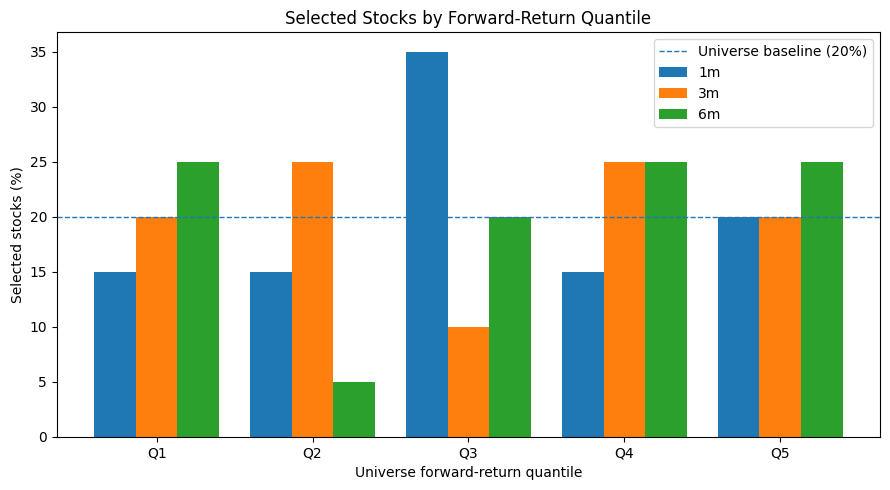

In [13]:
kw = dict(
    horizons = [1,3,6],
    plot = 'distribution',
    universe = features, 
)
_ = evaluate_selection(selected, prices, **kw)

# Recipes

In [114]:
from itertools import product
from stocksift.stock_assessment import StockAssessment
from stocksift.selection_policy_long import (
    LongThresholdFilter as LongFilter, 
    LongEqualFeatureScore as LongFeature,
    LongEqualGroupScore as LongGroup
)
from stocksift.selection_recipes_long import apply_selection, evaluate_selection

In [15]:
DATA_DIR = '../pf/data'
PRICE_CSV = "kospi200_prices_260814.csv"
RATIO_CSV = "kospi200_ratios_260814.csv"

In [16]:
# 1. Produce the canonical ticker-level assessment feature table.
assessment = StockAssessment(DATA_DIR)
prices, ratios = assessment.load_inputs(PRICE_CSV, RATIO_CSV)

In [17]:
date = '2025-09-01'
features = assessment.assess(prices, ratios, as_of=date)
print(f"Assessment universe: {len(features)}")

Assessment universe: 200


## Rule variants
Add / remove / modify features here while testing

In [55]:
ft1 = [
    ("per_hist_pct", "<=", 50.0),
    ("eps_growth_pct", ">=", 50.0),
    ("momentum_12m_pct", ">=", 50.0),
]

ft2 = [
    ("per_hist_pct", "<=", 80.0),
    ("eps_growth_pct", ">=", 20.0),
    ("momentum_12m_pct", ">=", 20.0),
]

v1 = {
    "per_hist_pct": "lower",
    "pbr_hist_pct": "lower",
}

v2 = {
    "per_expansion_pct": "lower",
    "pbr_expansion_pct": "lower",
}


f1 =  {
    "eps_growth_pct": "higher",
    "bps_growth_pct": "higher",
    #"dps_growth_pct": "higher",
}

m1 = {
    "momentum_6m_pct": "higher",
    #"momentum_12m_pct": "higher",
}

In [119]:
n = 20

#policies = [LongFilter(ft2)]
#policies = [LongFeature(f1, top_n=n)]
#policies = [LongFeature(v2, top_n=n)]
#policies = [LongFeature(m1, top_n=n)]
##policies = [LongFilter(ft1)]
##policies = [LongFeature(v1, top_n=n)]

#policies = [LongFilter(ft2), LongFeature(f1, top_n=n)]
#policies = [LongFilter(ft2), LongFeature(v2, top_n=n)]
#policies = [LongFilter(ft2), LongFeature(m1, top_n=n)]
##policies = [LongFilter(ft2), LongFeature(v1, top_n=n)]

In [151]:
n = 20

make_group = lambda v, f, m=None: LongGroup({
    'valuation': v, 'fundamentals': f,
    **({} if m is None else {'momentum': m}),
}, top_n=n)

policies = [LongFilter(ft2), make_group(v2, f1, m1)]
#policies = [LongFilter(ft2), make_group(v1, f1, m1)]
#policies = [LongFilter(ft2), make_group(v2, f1)]
#policies = [LongFilter(ft2), make_group(v1, f1)]
#policies = [make_group(v2, f1, m1)]
#policies = [make_group(v1, f1)]
#policies = [make_group(v2, f1)]
#policies = [LongFilter(ft1), make_group(v2, f1, m1)]

In [152]:
selected = apply_selection(
    features,
    policies=policies,
)

Selected: 200 -> 64 -> 20


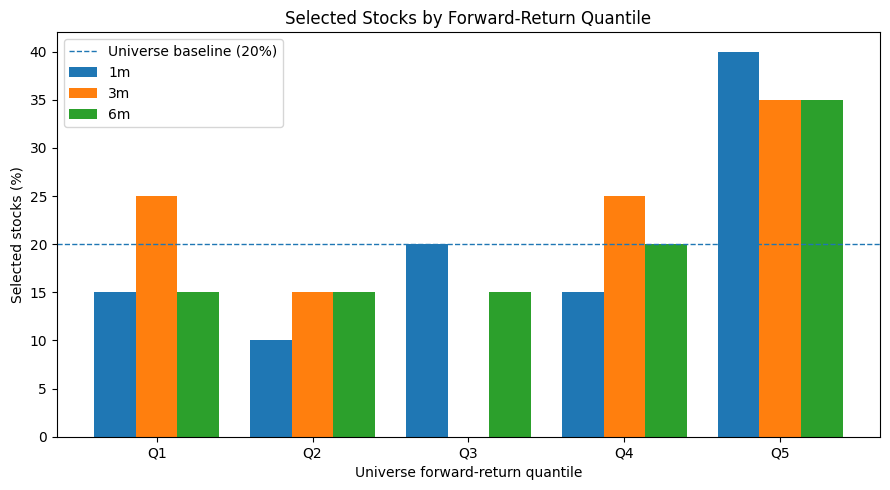

In [157]:
_ = evaluate_selection(
    selected,
    prices,
    universe=features,
    horizons = [1,3,6],
    plot='distribution',
)

In [158]:
result = evaluate_selection(
    selected,
    prices,
    universe=features,
    horizons = [1,3,6],
    result="summary",
)
result

,horizon,selected_count,universe_count,selected_mean_return,universe_mean_return,mean_excess_return,selected_median_return,universe_median_return,median_excess_return,top_quantile_hit_rate,bottom_quantile_hit_rate,quantile_baseline_rate,selected_mean_percentile
0,1m,20,200,0.067435,0.027256,0.040180,0.036379,0.007716,0.028664,0.40,0.15,0.2,62.6875
1,3m,20,200,0.151175,0.124728,0.026447,0.155538,0.070458,0.085081,0.35,0.25,0.2,54.5750
2,6m,20,200,0.639889,0.440851,0.199038,0.447045,0.297526,0.149519,0.35,0.15,0.2,58.6000


In [159]:
result.to_dict()

{'horizon': {0: '1m', 1: '3m', 2: '6m'},
 'selected_count': {0: 20, 1: 20, 2: 20},
 'universe_count': {0: 200, 1: 200, 2: 200},
 'selected_mean_return': {0: 0.06743544756449693,
  1: 0.15117518655756124,
  2: 0.6398888352197201},
 'universe_mean_return': {0: 0.02725584174789467,
  1: 0.1247277230906267,
  2: 0.44085050273117615},
 'mean_excess_return': {0: 0.040179605816602265,
  1: 0.026447463466934537,
  2: 0.1990383324885439},
 'selected_median_return': {0: 0.03637932315146519,
  1: 0.15553838181820878,
  2: 0.44704504706875825},
 'universe_median_return': {0: 0.007715755533933999,
  1: 0.07045770061692291,
  2: 0.297525677989008},
 'median_excess_return': {0: 0.028663567617531194,
  1: 0.08508068120128587,
  2: 0.14951936907975028},
 'top_quantile_hit_rate': {0: 0.4, 1: 0.35, 2: 0.35},
 'bottom_quantile_hit_rate': {0: 0.15, 1: 0.25, 2: 0.15},
 'quantile_baseline_rate': {0: 0.2, 1: 0.2, 2: 0.2},
 'selected_mean_percentile': {0: 62.6875, 1: 54.575, 2: 58.6}}

In [47]:
# 2. Threshold eligibility example. Passing rows have no priority ranking.
threshold = LongThresholdFilter(
    rules=[
        ("per_hist_pct", "<=", 50),
        ("eps_growth_pct", ">=", 50),
        ("momentum_12m_pct", ">=", 50),
    ]
)
eligible = threshold.select(features)
print(f"Threshold eligible: {len(eligible)}")
print(threshold.trace(features).to_string(index=False))

Threshold eligible: 20
 step          feature operator threshold  remaining
    0 initial_universe               <NA>        200
    1     per_hist_pct       <=      50.0         74
    2   eps_growth_pct       >=      50.0         51
    3 momentum_12m_pct       >=      50.0         20


In [51]:
# 5. Compose policies while continuing to use the same canonical feature table.
selected = candidates.select(
    features,
    tickers=eligible["ticker"],
)
print("\nTop N within threshold-eligible tickers")

selected


Top N within threshold-eligible tickers


,ticker,as_of_date,price,BPS,PER,PBR,EPS,DIV,DPS,per_smoothed,...,momentum_12m_pct,volatility_60d,max_drawdown_12m,volatility_risk_pct,drawdown_risk_pct,valuation_score,fundamentals_score,momentum_score,selection_score,selection_rank
0,443060,2025-09-01,204000.0,17402.0,38.46,11.72,5304.0,1.54,3150.0,37.300,...,89.847716,0.427518,-0.356853,52.261307,70.351759,65.775291,82.263374,87.853151,78.630605,1
1,267260,2025-09-01,487000.0,41725.0,34.95,11.67,13935.0,1.10,5350.0,35.250,...,79.695431,0.475213,-0.404494,64.321608,81.909548,56.490642,93.661488,80.504281,76.885470,2
2,006800,2025-09-01,18758.0,20662.0,12.19,0.91,1545.0,1.33,250.0,11.860,...,91.370558,0.539227,-0.241348,77.889447,31.155779,47.782559,84.995167,94.422653,75.733460,3
3,039490,2025-09-01,200500.0,210068.0,6.41,0.95,31269.0,3.74,7500.0,6.565,...,74.619289,0.487961,-0.214388,65.829146,20.603015,54.086779,89.692232,83.016715,75.598575,4
4,012450,2025-09-01,916000.0,108184.0,19.91,8.47,46002.0,0.38,3500.0,19.335,...,95.431472,0.497394,-0.329328,68.341709,62.311558,42.614606,94.487952,89.634928,75.579162,5
5,161890,2025-09-01,75900.0,33579.0,19.82,2.26,3830.0,0.95,720.0,20.730,...,52.791878,0.532039,-0.346457,76.884422,68.341709,77.039546,82.963675,55.183818,71.729013,6
6,271560,2025-09-01,108200.0,87815.0,8.15,1.23,13271.0,2.31,2500.0,8.150,...,53.807107,0.229439,-0.168637,5.025126,8.542714,83.710390,84.419339,43.317695,70.482475,7
7,192820,2025-09-01,211000.0,41725.0,27.90,5.06,7562.0,1.09,2300.0,28.595,...,86.294416,0.633191,-0.325887,90.452261,60.301508,43.786819,90.119830,71.682562,68.529737,8
8,000240,2025-09-01,23900.0,47012.0,6.45,0.51,3703.0,4.18,1000.0,6.355,...,68.527919,0.452357,-0.319660,59.798995,58.291457,51.176538,75.745536,75.425576,67.449216,9
9,016360,2025-09-01,68000.0,82018.0,6.75,0.83,10068.0,5.15,3500.0,6.800,...,70.050761,0.360339,-0.170611,37.185930,10.050251,49.188203,76.858679,75.176896,67.074593,10


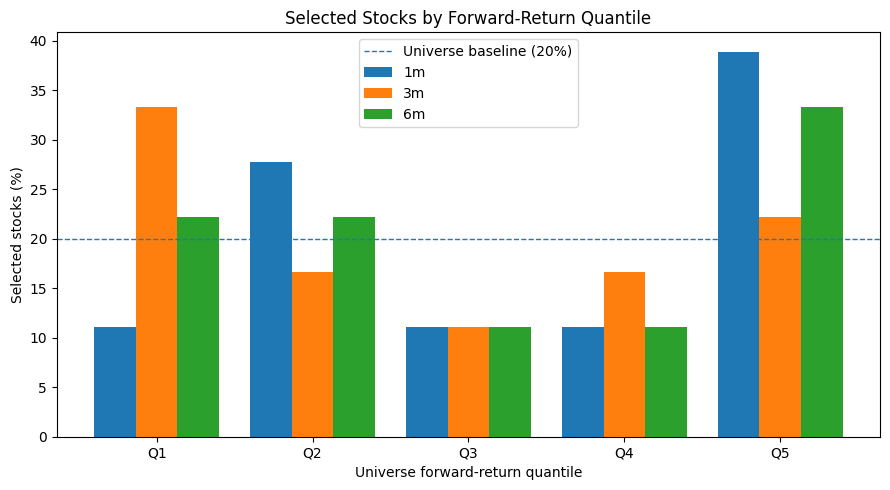

In [52]:
#horizons = (1,5,10)
horizons = (1,3,6)
details, distribution, summary = compare_selection_to_universe(
    selected,
    features,
    prices,
    horizons=horizons
)
_ = plot_forward_return_distribution(
    distribution
)

# Recipes

In [13]:
from stocksift.stock_assessment import StockAssessment
from stocksift.selection_recipes_long import (
    apply_selection,
    evaluate_recipe,
    evaluate_selected_forward_returns,
    plot_forward_returns,
    compare_selection_to_universe,
    plot_forward_return_distribution
)

In [16]:
DATA_DIR = '../pf/data'
PRICE_CSV = "kospi200_prices_260814.csv"
RATIO_CSV = "kospi200_ratios_260814.csv"

In [17]:
assessment = StockAssessment(DATA_DIR)
prices, ratios = assessment.load_inputs(PRICE_CSV, RATIO_CSV)

In [18]:
date = '2025-09-01'
#date = None

# Current selection
features = assessment.assess(
    prices,
    ratios,
    as_of = date
)

In [20]:
selected = apply_selection(features)

<Axes: title={'center': 'Forward Returns by Selected Stock'}, xlabel='Forward horizon', ylabel='Return'>

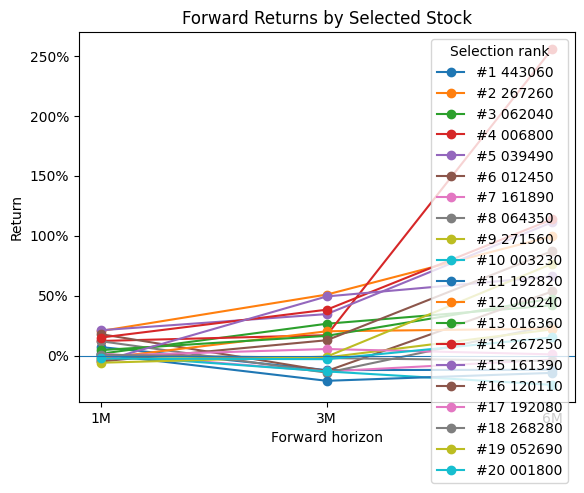

In [7]:
# Evaluate the already-produced selection
evaluated = evaluate_selected_forward_returns(
    selected,
    prices,
    price_date_col=assessment.price_cols["date"],
)

plot_forward_returns(evaluated)

In [12]:
from selection_policy_long import LongThresholdFilter, LongEqualGroupScore


CORE_LONG_THRESHOLD_RULES = (
    ("per_hist_pct", "<=", 50.0),
    ("eps_growth_pct", ">=", 50.0),
    ("momentum_12m_pct", ">=", 50.0),
)

policies = [
    LongThresholdFilter(rules=CORE_LONG_THRESHOLD_RULES),
    LongEqualGroupScore(top_n=5),
]

<Axes: title={'center': 'Forward Returns by Selected Stock'}, xlabel='Forward horizon', ylabel='Return'>

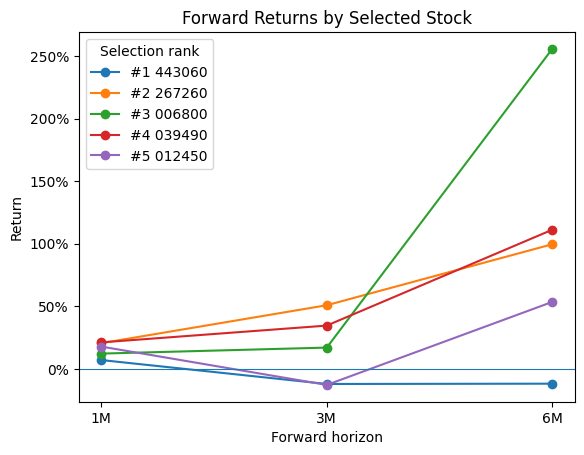

In [37]:
# Historical point-in-time evaluation:
# regenerate features as of the date -> apply recipe -> forward returns
evaluated = evaluate_recipe(
    assessment,
    prices,
    ratios,
    as_of=date,
    horizons=(1, 3, 6),
    policies=policies
)

plot_forward_returns(evaluated)

In [38]:
details, distribution, summary = compare_selection_to_universe(
    evaluated,
    features,
    prices,
    horizons = (1, 3, 6)
)

In [39]:
distribution

,horizon,quantile,selected_count,selected_proportion,baseline_proportion
0,1m,Q1,0,0.0,0.2
1,1m,Q2,0,0.0,0.2
2,1m,Q3,0,0.0,0.2
3,1m,Q4,1,0.2,0.2
4,1m,Q5,4,0.8,0.2
5,3m,Q1,2,0.4,0.2
6,3m,Q2,0,0.0,0.2
7,3m,Q3,0,0.0,0.2
8,3m,Q4,1,0.2,0.2
9,3m,Q5,2,0.4,0.2


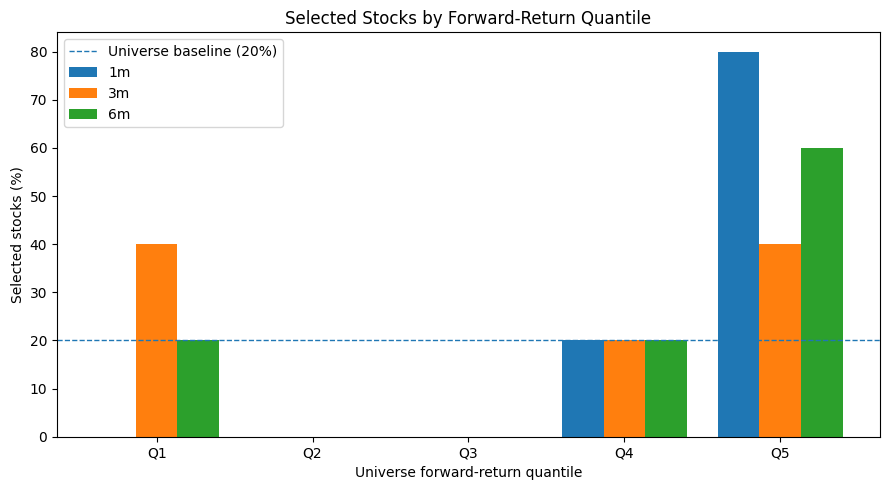

In [42]:
_ = plot_forward_return_distribution(
    distribution
)